In [16]:
import asyncio

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.messages import TextMessage
from autogen_core import CancellationToken
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_ext.tools.http import HttpTool
from autogen_core.models import UserMessage
from autogen_ext.models.ollama import OllamaChatCompletionClient
from typing import Any, Dict, List

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import HandoffTermination, TextMentionTermination
from autogen_agentchat.messages import HandoffMessage
from autogen_agentchat.teams import Swarm
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import OpenAIChatCompletionClient

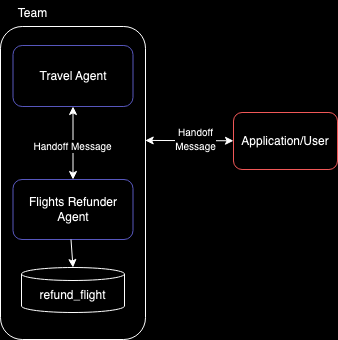

In [17]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
import json
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
open_router_api_key= os.getenv("OPENROUTER_API_KEY")

We can make Parallel Tool call to False, so that it will not call tools parallely

In [18]:

model=ChatGroq(model="qwen-qwq-32B")
def llm(input):
    model=ChatGroq(model="qwen-qwq-32B")
    output=model.invoke(input)
    return output.content
print(model)

model1=OpenAIChatCompletionClient(model="gpt-4o")
print(model1)

client=<groq.resources.chat.completions.Completions object at 0x13057c0e0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1305ef860> model_name='qwen-qwq-32B' model_kwargs={} groq_api_key=SecretStr('**********')


In [19]:

open_router_model_client = OpenAIChatCompletionClient(
    base_url="https://openrouter.ai/api/v1",
    model="nvidia/llama-3.1-nemotron-70b-instruct",
    api_key=open_router_api_key,
    model_info={
        "family": 'deepseek',
        "vision": True,
        "function_calling": True,
        "json_output": False
    }
)
response = open_router_model_client.create([UserMessage(content="What is the capital of France?", source="user")])

print(response)

<coroutine object BaseOpenAIChatCompletionClient.create at 0x1272ba880>


/Users/arunkumar/anaconda3/envs/py312/lib/python3.12/site-packages/autogen_ext/models/openai/_openai_client.py:439: UserWarning: Missing required field 'structured_output' in ModelInfo. This field will be required in a future version of AutoGen.
  validate_model_info(self._model_info)
/var/folders/4m/z36lvyp57r37vs_gdh88c2mc0000gn/T/ipykernel_94720/674734784.py:12: RuntimeWarning: coroutine 'BaseOpenAIChatCompletionClient.create' was never awaited
  response = open_router_model_client.create([UserMessage(content="What is the capital of France?", source="user")])


In [20]:
def refund_flight(flight_id: str) -> str:
    """Refund a flight"""
    return f"Flight {flight_id} refunded"

Using RoundRobin manner nothing is possible, Hand off is not there in RoudRobin

In Handoff we have to give it over Travel_Agent, Flight_Refeunder just by using PNR Number and the Termination conditon is passed to User

In [21]:
travel_agent = AssistantAgent(
    "travel_agent",
    model_client=open_router_model_client,
    handoffs=["flights_refunder", "user"],
    system_message="""You are a travel agent.
    The flights_refunder is in charge of refunding flights.
    If you need information from the user, you must first send your message, then you can handoff to the user.
    Use TERMINATE when the travel planning is complete.""",
)

flights_refunder = AssistantAgent(
    "flights_refunder",
    model_client=model1,
    handoffs=["travel_agent", "user"],
    tools=[refund_flight],
    system_message="""You are an agent specialized in refunding flights.
    You only need flight reference numbers to refund a flight.
    You have the ability to refund a flight using the refund_flight tool.
    If you need information from the user, you must first send your message, then you can handoff to the user.
    When the transaction is complete, handoff to the travel agent to finalize.""",
)

In [22]:
#the Termination conditon is passed to User
termination = HandoffTermination(target="user") | TextMentionTermination("TERMINATE")
team = Swarm([travel_agent, flights_refunder], termination_condition=termination)


Good MODEL has Parallel tool call, if free model is used the tool calling is not proper and it is calling again and agiann, which mess up 

In [9]:
task= 'please refunfd my flight'

async def run_team_stream() ->None :
    task_result= await Console(team.run_stream(task=task))
    last_message=task_result.messages[-1]
    while(isinstance(last_message,HandoffMessage) and last_message.target=='user'):
        user_sends_msg=input("User :")
        task_result= await Console(team.run_stream(task=HandoffMessage(source='user',target=last_message.source,content=user_sends_msg)))
        last_message=task_result.messages[-1]
    
await run_team_stream()


---------- TextMessage (user) ----------
please refunfd my flight
---------- ThoughtEvent (travel_agent) ----------
**First, a quick confirmation from me (Travel Agent) before I hand over the process to the flights_refunder:**

* **Confirmation Message**: "To process your flight refund, please confirm the following:
	+ Your Flight Number: _____________________
	+ Reason for Refund (optional, but helpful): _____________________
	+ Are there any other travel arrangements (e.g., hotel, car rental) you'd like to adjust/refund concurrently? _____________________"

**Now, handing over to the user to collect the necessary confirmation and details:**


---------- ToolCallRequestEvent (travel_agent) ----------
[FunctionCall(id='call_n7OxCug5hMIoHv1rdVbJ4weh', arguments='{"message": "Please respond with the requested flight refund details to facilitate the process. See below for details.", "details": ["Confirm Flight Number", "Reason for Refund (if any)", "Other travel arrangements adjustment/re

/Users/arunkumar/anaconda3/envs/py312/lib/python3.12/site-packages/autogen_agentchat/agents/_assistant_agent.py:1107: UserWarning: Finish reason mismatch: stop != tool_calls when tool_calls are present. Finish reason may not be accurate. This may be due to the API used that is not returning the correct finish reason.
  model_result = await model_client.create(


---------- HandoffMessage (user) ----------
PNR12345
---------- ThoughtEvent (travel_agent) ----------
**User's Response Adopted:**

* **Flight Confirmation**:
	+ **Flight Number (PNR)**: PN12345
	+ **Reason for Refund**: Not Provided
	+ **Other Travel Arrangements**: Not Mentioned

**Travel Agent's Response After Receiving User Input:**

"Thank you for providing the necessary details. We have located your booking under PNR12345. Before proceeding with the refund, please note the following:

* Refund Policy: [Briefly mention the policy, e.g., 'partial refund due to cancellation fees']
* Refund Amount: [Provide an estimate if possible, e.g., '$X amount']
* Refund Processing Time: [Mention the timeframe, e.g., 'within the next 7-10 working days']

**Handing Over to Flights Refunder for Final Processing:**


---------- ToolCallRequestEvent (travel_agent) ----------
[FunctionCall(id='call_jFLGSXixgwSIGbXyj5CyOKCR', arguments='{"PNR": "PNR12345", "refund_details": {"policy": "[Insert Policy